 ## STL Disease - VGG16 (CUT_LAYER=7) + K-Fold + GradCAM

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
### Nota importante:
# He eliminado ISIC_0028189 del conjunto de train, porque era corrupta.

2026-04-28 18:45:02.449201: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 7
N_FOLDS     = 5
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CUT_LAYER   = 7

WARMUP_EPOCHS, FT_EPOCHS = 30, 30
WARMUP_LR = 1e-3          # LR warmup (solo heads)
FT_LR     = 1e-5          # LR fine-tuning (todo el modelo descongelado)
TASK_NAME = "disease"   

EXP_DIR = Path("VGG16_STL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{TASK_NAME}_CUT{CUT_LAYER}_{N_FOLDS}fold"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento STL ({TASK_NAME}) en: {EXP_DIR.resolve()}")

Experimento STL (disease) en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Disease_experimentos/VGG16_STL/exp_2026-04-28_18-45_disease_CUT7_5fold


In [3]:
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

print(f"CSVs - train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}")

for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Etiquetas de disease
y_train = df_train[class_cols].values.astype("float32")
y_val   = df_val[class_cols].values.astype("float32")
y_test  = df_test[class_cols].values.astype("float32")

df_trainval    = pd.concat([df_train, df_val], ignore_index=True)
y_trainval     = np.concatenate([y_train, y_val], axis=0)
y_trainval_int = np.argmax(y_trainval, axis=1)
y_test_int     = np.argmax(y_test, axis=1)

print("\n" + "="*60)
print(f"DISTRIBUCIÓN DE ETIQUETAS - tarea: {TASK_NAME}")
print("="*60)
for i, c in enumerate(class_names):
    n = (y_trainval_int == i).sum()
    print(f"  {c:<7} {n:>5}  ({100*n/len(y_trainval_int):.1f}%)")
print(f"\nTest set fijo: {len(df_test)} imágenes")

# Class weights balanceados
cw = compute_class_weight(class_weight="balanced",
                           classes=np.arange(NUM_CLASSES),
                           y=y_trainval_int)
CW = tf.constant(cw, dtype=tf.float32)
class_weight_dict = {i: float(cw[i]) for i in range(NUM_CLASSES)}
print(f"\nClass weights: {cw.round(3)}")

CSVs — train: 6008  val: 2003  test: 2003

DISTRIBUCIÓN DE ETIQUETAS — tarea: disease
  akiec     261  (3.3%)
  bcc       411  (5.1%)
  bkl       880  (11.0%)
  df         92  (1.1%)
  mel       890  (11.1%)
  nv       5363  (66.9%)
  vasc      114  (1.4%)

Test set fijo: 2003 imágenes

Class weights: [ 4.385  2.784  1.3   12.439  1.286  0.213 10.039]


2026-04-28 18:45:03.392359: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-04-28 18:45:03.415558: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:06:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.92GiB deviceMemoryBandwidth: 451.17GiB/s
2026-04-28 18:45:03.415595: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-04-28 18:45:03.417131: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-04-28 18:45:03.418493: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-04-28 18:45:03.418723: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [4]:
def load_image(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, y

def load_image_aug(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, y

def make_dataset(filepaths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_aug if training else load_image, num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds

test_ds = make_dataset(df_test["filepath"].values, y_test, training=False)

print("Sanity check:")
for imgs, y in test_ds.take(1):
    print(f"  imgs: {imgs.shape}  y: {y.shape}")

Sanity check:
  imgs: (32, 224, 224, 3)  y: (32, 7)


In [5]:
def build_model():
    base_model = tf.keras.applications.VGG16(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    x = tf.keras.layers.Dropout(0.3, name="shared_dropout")(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax",
                                 name=f"head_{TASK_NAME}")(x)
    model = tf.keras.Model(inputs=inputs, outputs=out, name=f"STL_VGG16_{TASK_NAME}")
    return model, base_model

# Visualización
_tmp_m, _tmp_b = build_model()
_tmp_m.summary()
tf.keras.utils.plot_model(_tmp_m, to_file=str(EXP_DIR / "00_model_architecture.png"),
                           show_shapes=True, show_layer_names=True,
                           expand_nested=True, dpi=150)
del _tmp_m, _tmp_b
tf.keras.backend.clear_session()

Model: "STL_VGG16_disease"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 224, 224, 3)]     0         
_________________________________________________________________
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
gap (GlobalAveragePooling2D) (None, 512)               0         
_________________________________________________________________
shared_dense (Dense)         (None, 256)               131328    
_________________________________________________________________
shared_dropout (Dropout)     (None, 256)               0         
_________________________________________________________________
head_disease (Dense)         (None, 7)                 1799      
Total params: 14,847,815
Trainable params: 133,127
Non-trainable params: 14,714,688
_______________________________

In [7]:
def unfreeze_from(base_model, cut_layer):
    base_model.trainable = True
    for layer in base_model.layers:
        layer.trainable = False
    for i, layer in enumerate(base_model.layers):
        if i >= cut_layer:
            layer.trainable = True
    trainable = sum(l.count_params() for l in base_model.layers if l.trainable)
    total     = base_model.count_params()
    print(f"cut_layer={cut_layer} -> {trainable:,}/{total:,} params trainable "
          f"({100*trainable/total:.1f}%)")

print("Helper unfreeze listo.")

Helper unfreeze listo.


In [8]:
def train_one_fold(fold_idx, train_idx, val_idx, fold_dir):
    fold_dir.mkdir(exist_ok=True)
    print(f"\n{'='*70}\nFOLD {fold_idx}/{N_FOLDS} - STL {TASK_NAME}\n{'='*70}")

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    y_tr  = df_tr[class_cols].values.astype("float32")
    y_vl  = df_vl[class_cols].values.astype("float32")

    print(f"  train={len(df_tr)}  val={len(df_vl)}  test(fijo)={len(df_test)}")

    train_ds = make_dataset(df_tr["filepath"].values, y_tr, training=True)
    val_ds   = make_dataset(df_vl["filepath"].values, y_vl, training=False)

    model, base_model = build_model()

    #FASE 1: WARMUP
    print(f"\n--- FASE 1: warmup (head only, LR={WARMUP_LR}) ---")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=WARMUP_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks_warmup = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=7, min_delta=0.005,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]
    t0 = time.time()
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=WARMUP_EPOCHS,
                    class_weight=class_weight_dict,
                    callbacks=callbacks_warmup, verbose=2)
    t_warmup = time.time() - t0

    #FASE 2: FINE-TUNING 
    print(f"\n--- FASE 2: fine-tuning (CUT_LAYER={CUT_LAYER}, LR={FT_LR}) ---")
    unfreeze_from(base_model, CUT_LAYER)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FT_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks_ft = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, min_delta=0.005,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]
    t0 = time.time()
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=FT_EPOCHS,
                    class_weight=class_weight_dict,
                    callbacks=callbacks_ft, verbose=2)
    t_ft = time.time() - t0

    #History combinada 
    h1_dict = h1.history
    h2_dict = h2.history
    history = {k: list(h1_dict.get(k, [])) + list(h2_dict.get(k, [])) for k in h1_dict}
    pd.DataFrame(history).to_csv(fold_dir / "history.csv", index=False)

    #Evaluación sobre test 
    print(f"\n--- Evaluación sobre test ({len(df_test)} imgs) ---")
    t0 = time.time()
    y_pred_proba = model.predict(test_ds, verbose=0)
    t_predict = time.time() - t0
    y_pred_int = np.argmax(y_pred_proba, axis=1)

    metrics = {
        "fold":           fold_idx,
        "time_warmup_s":  round(t_warmup, 1),
        "time_ft_s":      round(t_ft, 1),
        "time_total_s":   round(t_warmup + t_ft, 1),
        "time_predict_s": round(t_predict, 2),
        "epochs_warmup":  len(h1_dict["loss"]),
        "epochs_ft":      len(h2_dict["loss"]),
        "len_warmup":     len(h1_dict["loss"]),
        f"{TASK_NAME}_acc":          float((y_test_int == y_pred_int).mean()),
        f"{TASK_NAME}_balanced_acc": float(balanced_accuracy_score(y_test_int, y_pred_int)),
        f"{TASK_NAME}_f1_macro":     float(f1_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
        f"{TASK_NAME}_f1_weighted":  float(f1_score(y_test_int, y_pred_int, average="weighted", zero_division=0)),
        f"{TASK_NAME}_kappa":        float(cohen_kappa_score(y_test_int, y_pred_int)),
    }
    try:
        y_true_onehot = np.eye(NUM_CLASSES)[y_test_int]
        metrics[f"{TASK_NAME}_auc_macro"] = float(
            roc_auc_score(y_true_onehot, y_pred_proba, multi_class="ovr", average="macro"))
    except Exception:
        metrics[f"{TASK_NAME}_auc_macro"] = float("nan")

    if TASK_NAME == "disease":
        metrics["auc_melanoma"] = float(roc_auc_score(
            (y_test_int == 4).astype(int), y_pred_proba[:, 4]))

    (fold_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

    rpt = classification_report(y_test_int, y_pred_int,
                                 target_names=class_names, digits=4)
    (fold_dir / f"classification_report_{TASK_NAME}.txt").write_text(rpt)
    print(f"\n--- {TASK_NAME.upper()} ---\n{rpt}")

    cm = confusion_matrix(y_test_int, y_pred_int)
    np.save(fold_dir / f"confusion_matrix_{TASK_NAME}.npy", cm)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(f"Fold {fold_idx} - {TASK_NAME} (test)")
    plt.tight_layout()
    plt.savefig(fold_dir / f"confusion_matrix_{TASK_NAME}.png", dpi=100)
    plt.show()

    model.save_weights(str(fold_dir / "best_weights"), save_format="tf")
    print(f"  Pesos guardados en: {fold_dir / 'best_weights'}")

    return {
        "metrics":      metrics,
        "y_pred_int":   y_pred_int,
        "y_pred_proba": y_pred_proba,
        "h1_history":   h1_dict,
        "h2_history":   h2_dict,
    }

print("train_one_fold STL listo.")

train_one_fold STL listo.



FOLD 1/5 — STL disease
  train=6408  val=1603  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30


2026-04-28 18:45:06.717492: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-04-28 18:45:06.956650: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


201/201 - 18s - loss: 2.1204 - accuracy: 0.3546 - val_loss: 1.3261 - val_accuracy: 0.5434
Epoch 2/30
201/201 - 18s - loss: 1.2820 - accuracy: 0.5183 - val_loss: 1.2251 - val_accuracy: 0.5253
Epoch 3/30
201/201 - 18s - loss: 1.1161 - accuracy: 0.5581 - val_loss: 1.1260 - val_accuracy: 0.5858
Epoch 4/30
201/201 - 18s - loss: 0.9789 - accuracy: 0.5846 - val_loss: 1.0565 - val_accuracy: 0.6176
Epoch 5/30
201/201 - 18s - loss: 0.9048 - accuracy: 0.6131 - val_loss: 0.9451 - val_accuracy: 0.6394
Epoch 6/30
201/201 - 18s - loss: 0.8860 - accuracy: 0.6152 - val_loss: 1.1367 - val_accuracy: 0.5590
Epoch 7/30
201/201 - 18s - loss: 0.8537 - accuracy: 0.6174 - val_loss: 0.8933 - val_accuracy: 0.6694
Epoch 8/30
201/201 - 18s - loss: 0.7660 - accuracy: 0.6389 - val_loss: 0.8116 - val_accuracy: 0.6943
Epoch 9/30
201/201 - 18s - loss: 0.7559 - accuracy: 0.6522 - val_loss: 1.1386 - val_accuracy: 0.5621
Epoch 10/30
201/201 - 18s - loss: 0.7282 - accuracy: 0.6473 - val_loss: 0.9561 - val_accuracy: 0.6095


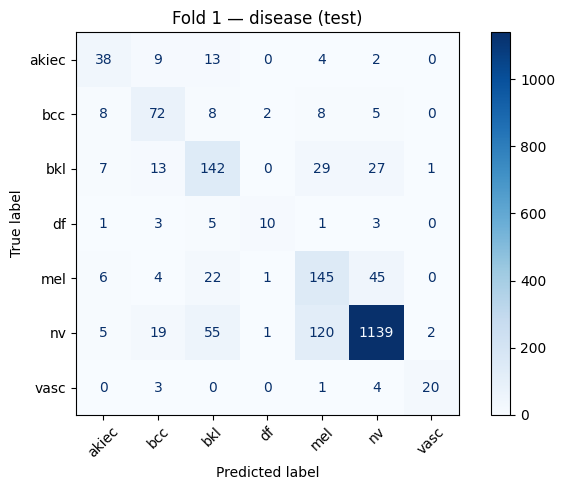

  Pesos guardados en: VGG16_STL/exp_2026-04-28_18-45_disease_CUT7_5fold/fold_1/best_weights

FOLD 2/5 — STL disease
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 19s - loss: 2.0969 - accuracy: 0.3821 - val_loss: 1.0763 - val_accuracy: 0.6236
Epoch 2/30
201/201 - 18s - loss: 1.2717 - accuracy: 0.4948 - val_loss: 1.2529 - val_accuracy: 0.5112
Epoch 3/30
201/201 - 18s - loss: 1.1160 - accuracy: 0.5578 - val_loss: 1.4356 - val_accuracy: 0.4501
Epoch 4/30

Epoch 00004: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 - 18s - loss: 1.0554 - accuracy: 0.5687 - val_loss: 1.1061 - val_accuracy: 0.5668
Epoch 5/30
201/201 - 18s - loss: 0.8704 - accuracy: 0.6066 - val_loss: 0.9571 - val_accuracy: 0.6504
Epoch 6/30
201/201 - 18s - loss: 0.8256 - accuracy: 0.6313 - val_loss: 0.9242 - val_accuracy: 0.6548
Epoch 7/30
201/201 - 18s - loss: 0.7953 - accuracy: 0.6453 - val_loss: 0.9161 - val_accuracy: 0.6554
Epoch 8/30

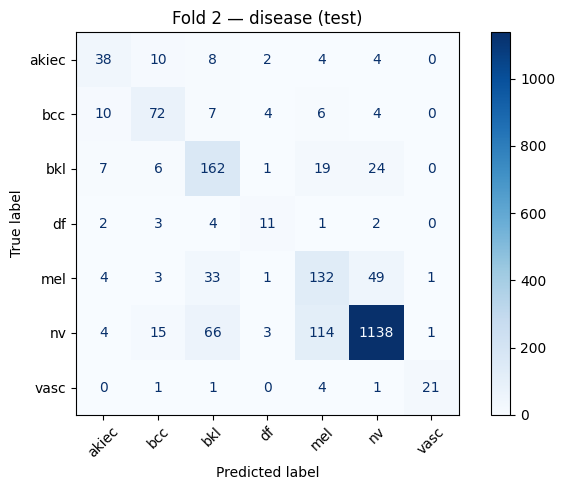

  Pesos guardados en: VGG16_STL/exp_2026-04-28_18-45_disease_CUT7_5fold/fold_2/best_weights

FOLD 3/5 — STL disease
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 19s - loss: 2.0863 - accuracy: 0.3568 - val_loss: 1.3140 - val_accuracy: 0.5012
Epoch 2/30
201/201 - 18s - loss: 1.2602 - accuracy: 0.5143 - val_loss: 1.0003 - val_accuracy: 0.6267
Epoch 3/30
201/201 - 18s - loss: 1.0933 - accuracy: 0.5612 - val_loss: 1.2055 - val_accuracy: 0.5406
Epoch 4/30
201/201 - 18s - loss: 0.9561 - accuracy: 0.5951 - val_loss: 1.0805 - val_accuracy: 0.5949
Epoch 5/30

Epoch 00005: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 - 18s - loss: 0.9027 - accuracy: 0.6102 - val_loss: 1.0004 - val_accuracy: 0.6498
Epoch 6/30
201/201 - 18s - loss: 0.7884 - accuracy: 0.6478 - val_loss: 0.9029 - val_accuracy: 0.6729
Epoch 7/30
201/201 - 18s - loss: 0.7640 - accuracy: 0.6516 - val_loss: 0.9469 - val_accuracy: 0.6442
Epoch 8/30

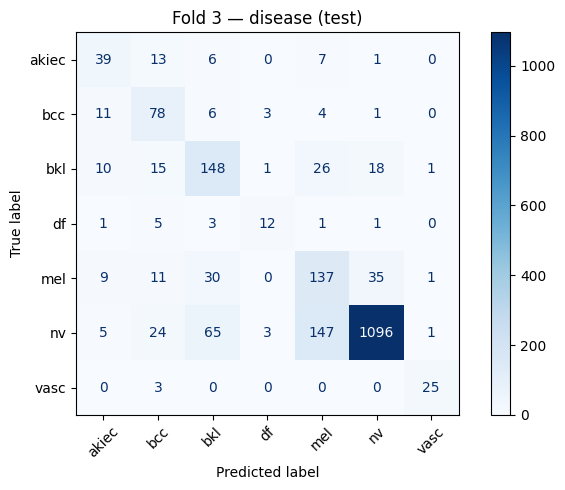

  Pesos guardados en: VGG16_STL/exp_2026-04-28_18-45_disease_CUT7_5fold/fold_3/best_weights

FOLD 4/5 — STL disease
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 18s - loss: 2.0158 - accuracy: 0.3910 - val_loss: 1.2962 - val_accuracy: 0.5443
Epoch 2/30
201/201 - 18s - loss: 1.3142 - accuracy: 0.5052 - val_loss: 1.1803 - val_accuracy: 0.5437
Epoch 3/30
201/201 - 18s - loss: 1.1189 - accuracy: 0.5715 - val_loss: 1.1622 - val_accuracy: 0.5393
Epoch 4/30
201/201 - 18s - loss: 1.0039 - accuracy: 0.5987 - val_loss: 1.0523 - val_accuracy: 0.6223
Epoch 5/30
201/201 - 18s - loss: 0.9321 - accuracy: 0.6102 - val_loss: 0.9912 - val_accuracy: 0.6067
Epoch 6/30
201/201 - 18s - loss: 0.8898 - accuracy: 0.6183 - val_loss: 1.0204 - val_accuracy: 0.5930
Epoch 7/30
201/201 - 18s - loss: 0.8350 - accuracy: 0.6235 - val_loss: 1.0228 - val_accuracy: 0.5874
Epoch 8/30
201/201 - 18s - loss: 0.7803 - accuracy: 0.6577 - val_loss: 0.8989 - val_accurac

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
all_fold_metrics = []
histories_warmup = []
histories_ft     = []
t_exp_start      = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(df_trainval)), y_trainval_int), 1):
    fold_dir = EXP_DIR / f"fold_{fold_idx}"
    result   = train_one_fold(fold_idx, train_idx, val_idx, fold_dir)
    all_fold_metrics.append(result["metrics"])
    histories_warmup.append(result["h1_history"])
    histories_ft.append(result["h2_history"])
    del result
    tf.keras.backend.clear_session()

t_exp_total = time.time() - t_exp_start
print(f"\n{'='*70}")
print(f"*** Experimento STL {TASK_NAME} completo en {t_exp_total/60:.1f} min ***")
print(f"{'='*70}")

df_metrics = pd.DataFrame(all_fold_metrics)
df_metrics.to_csv(EXP_DIR / "all_folds_metrics.csv", index=False)

# Summary con mediana
numeric  = [c for c in df_metrics.columns
            if c != "fold" and pd.api.types.is_numeric_dtype(df_metrics[c])]
summary  = df_metrics[numeric].agg(["mean", "median", "std"]).T
summary.columns = ["mean", "median", "std"]
summary["mean±std"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
summary.to_csv(EXP_DIR / "summary_mean_median_std.csv")

print("\n" + "="*70)
print(f"RESUMEN ENTRE {N_FOLDS} FOLDS - STL {TASK_NAME}")
print("="*70)
print(summary[["mean", "median", "std"]])
print(f"\nGuardado en: {EXP_DIR}")


#Funciones de curvas 
def _hist_to_dict(h):
    return h.history if hasattr(h, "history") else h

def _pad_to_len(arr, max_len):
    arr = np.asarray(arr, dtype=np.float32)
    out = np.full((max_len,), np.nan, dtype=np.float32)
    out[:min(len(arr), max_len)] = arr[:min(len(arr), max_len)]
    return out

def _stack_metric(histories, key):
    hs      = [_hist_to_dict(h) for h in histories]
    lens    = [len(h.get(key, [])) for h in hs]
    max_len = max(lens) if lens else 0
    if max_len == 0:
        return np.empty((0, 0), dtype=np.float32), 0
    stacked = np.vstack([_pad_to_len(h.get(key, []), max_len) for h in hs]).astype(np.float32)
    return stacked, max_len


def plot_cv_mean_std(histories, save_dir, prefix, band_alpha=0.20):
    os.makedirs(save_dir, exist_ok=True)
    keys = {"loss": ("loss", "val_loss"), "accuracy": ("accuracy", "val_accuracy")}
    stacked, max_len = {}, 0
    for name, (k_tr, k_va) in keys.items():
        tr, ml = _stack_metric(histories, k_tr)
        va, _  = _stack_metric(histories, k_va)
        stacked[name] = (tr, va)
        max_len = max(max_len, ml)
    epochs = np.arange(1, max_len + 1)

    def mean_std(x):
        if x.size == 0:
            return np.full((max_len,), np.nan), np.full((max_len,), np.nan)
        return np.nanmean(x, axis=0), np.nanstd(x, axis=0)

    plt.figure(figsize=(14, 5))
    for i, name in enumerate(["loss", "accuracy"], 1):
        tr, va = stacked[name]
        m_tr, s_tr = mean_std(tr); m_va, s_va = mean_std(va)
        plt.subplot(1, 2, i)
        plt.plot(epochs, m_tr, linewidth=2, label=f"train {name} mean")
        plt.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=band_alpha)
        plt.plot(epochs, m_va, linewidth=2, linestyle="--", label=f"val {name} mean")
        plt.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=band_alpha)
        plt.title(f"{prefix} - {name} (mean ± std entre folds)")
        plt.xlabel("epoch"); plt.ylabel(name)
        plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(save_dir, f"{prefix}_cv_mean_std.png")
    plt.savefig(fig_path, dpi=300); plt.show()
    return fig_path


def plot_cv_combined(histories_warmup, histories_ft, save_dir, prefix="combined"):
    """Warmup + FT en un único gráfico con línea divisoria."""
    os.makedirs(save_dir, exist_ok=True)
    histories_full, len_warmups = [], []
    for h1, h2 in zip(histories_warmup, histories_ft):
        combined = {k: list(h1.get(k, [])) + list(h2.get(k, [])) for k in h1}
        histories_full.append(combined)
        len_warmups.append(len(h1["loss"]))
    sep_epoch = int(round(np.mean(len_warmups)))

    keys = {"Loss":     ("loss", "val_loss"),
            "Accuracy": ("accuracy", "val_accuracy")}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (title, (k_tr, k_va)) in zip(axes, keys.items()):
        tr_stk, ml = _stack_metric(histories_full, k_tr)
        va_stk, _  = _stack_metric(histories_full, k_va)
        epochs = np.arange(1, ml + 1)
        m_tr = np.nanmean(tr_stk, axis=0); s_tr = np.nanstd(tr_stk, axis=0)
        m_va = np.nanmean(va_stk, axis=0); s_va = np.nanstd(va_stk, axis=0)

        ax.plot(epochs, m_tr, linewidth=2, label="train mean", color="C0")
        ax.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=0.2, color="C0")
        ax.plot(epochs, m_va, linewidth=2, linestyle="--", label="val mean", color="C1")
        ax.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=0.2, color="C1")

        ax.axvline(sep_epoch, color="gray", linewidth=1.5, linestyle="--",
                   label=f"inicio FT (epoch {sep_epoch})")
        ax.set_title(f"{title} - warmup + fine-tuning (mean ± std)")
        ax.set_xlabel("Epoch global"); ax.set_ylabel(title)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(save_dir, f"{prefix}_full_training.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"  Gráfica conjunta guardada: {fig_path}")
    return fig_path


#Generar plots 
save_dir = str(EXP_DIR / "training_plots_cv")

print("\n Fase 1 (warmup)")
fig1 = plot_cv_mean_std(histories_warmup, save_dir=save_dir, prefix="phase1_warmup")

print("\n Fase 2 (fine-tuning)")
fig2 = plot_cv_mean_std(histories_ft, save_dir=save_dir, prefix="phase2_finetune")

print("\n Entrenamiento completo (warmup + FT combinados)")
fig_combined = plot_cv_combined(histories_warmup, histories_ft,
                                 save_dir=save_dir, prefix="combined")


#Matriz de confusión agregada 
print("\n>>> Matriz de confusión agregada entre folds")
cms = []
for k in range(1, N_FOLDS + 1):
    cm_path = EXP_DIR / f"fold_{k}" / f"confusion_matrix_{TASK_NAME}.npy"
    if cm_path.exists():
        cms.append(np.load(cm_path))

if cms:
    cm_sum  = np.sum(cms, axis=0)
    cm_mean = cm_sum.astype(float) / len(cms)
    cm_norm = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(cm_mean, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{TASK_NAME} - CM promediada entre {len(cms)} folds")
    axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{TASK_NAME} - CM normalizada por fila (recall)")
    axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

    plt.tight_layout()
    out = EXP_DIR / f"confusion_matrix_{TASK_NAME}_aggregated.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Guardado: {out}")
else:
    print("[AVISO] No se encontraron CMs por fold")

In [ ]:
import cv2

#Parámetros 
GRADCAM_LAYER = "block5_conv3"


best_metric_col = f"{TASK_NAME}_balanced_acc"
best_fold_idx   = int(df_metrics[best_metric_col].idxmax()) + 1
print(f"Usando fold {best_fold_idx}  "
      f"({best_metric_col}={df_metrics[best_metric_col].max():.4f})")

fold_dir_best = EXP_DIR / f"fold_{best_fold_idx}"
weights_path  = fold_dir_best / "best_weights"


backbone_gc, base_gc = build_model()


for imgs, _ in test_ds.take(1):
    _ = backbone_gc(imgs[:1], training=False)

if (fold_dir_best / "best_weights.index").exists():
    backbone_gc.load_weights(str(weights_path))
    print(f"Pesos cargados desde {weights_path}")
else:
    print(f"[AVISO] No se encontró {weights_path}.index")


#GradCAM
def make_gradcam_heatmap(img_array, model, class_idx):
    vgg_sub = model.get_layer("vgg16")
    last_conv_name = GRADCAM_LAYER

    vgg_dual = tf.keras.Model(
        inputs=vgg_sub.input,
        outputs=[
            vgg_sub.get_layer(last_conv_name).output,
            vgg_sub.output,
        ],
    )

    gap_layer    = model.get_layer("gap")
    shared_dense = model.get_layer("shared_dense")
    shared_drop  = model.get_layer("shared_dropout")
    head_disease = model.get_layer("head_disease")

    with tf.GradientTape() as tape:
        conv_outputs, vgg_final = vgg_dual(img_array, training=False)
        x           = gap_layer(vgg_final)
        x           = shared_dense(x)
        x           = shared_drop(x, training=False)
        predictions = head_disease(x)
        loss        = predictions[:, class_idx]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()




def overlay_heatmap(img_orig, heatmap, alpha=0.45):
    heatmap_r = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
    colored   = cv2.applyColorMap((heatmap_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    colored   = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return (alpha * colored + (1 - alpha) * img_orig).astype(np.uint8)

def load_img_for_gradcam(filepath):
    raw      = tf.io.read_file(filepath)
    raw      = tf.image.decode_image(raw, channels=3, expand_animations=False)
    raw      = tf.image.resize(raw, IMG_SIZE)
    img_orig = raw.numpy().astype(np.uint8)
    img_pre  = tf.keras.applications.vgg16.preprocess_input(tf.cast(raw, tf.float32))
    return img_orig, tf.expand_dims(img_pre, 0)


#Plot matriz por clase 
def plot_gradcam_by_class(df_test, y_true_int, y_pred_int, y_pred_proba,
                           backbone_model, class_names, fold_label="", save_dir=None):
    """
    Matriz 4 × n_clases:
      Fila 1: MAL clasificadas (imagen original)
      Fila 2: GradCAM overlay de la mal clasificada
      Fila 3: BIEN clasificadas (imagen original)
      Fila 4: GradCAM overlay de la bien clasificada
    """
    n_cls = len(class_names)
    fig, axes = plt.subplots(4, n_cls, figsize=(3 * n_cls, 12))
    if n_cls == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(f"{fold_label} GradCAM buenas/malas por clase - Tarea: {TASK_NAME}",
                 fontsize=13, fontweight="bold")

    for ci, cname in enumerate(class_names):
        #MAL clasificadas
        mask_bad = (y_true_int == ci) & (y_pred_int != ci)
        idx_bad  = np.where(mask_bad)[0]
        if len(idx_bad) > 0:
            confidences = y_pred_proba[idx_bad, y_pred_int[idx_bad]]
            best        = idx_bad[np.argmax(confidences)]

            top2_idx    = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls    = class_names[top2_idx[0]]
            top2_cls    = class_names[top2_idx[1]]
            top1_prob   = y_pred_proba[best, top2_idx[0]]
            top2_prob   = y_pred_proba[best, top2_idx[1]]

            filepath    = df_test.iloc[best]["filepath"]
            image_id    = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap  = make_gradcam_heatmap(
                img_pre, backbone_model, class_idx=int(top2_idx[0]))
            overlay  = overlay_heatmap(img_orig, heatmap)

            axes[0, ci].imshow(img_orig)
            axes[0, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.6f})\n"
                f"top2: {top2_cls} ({top2_prob:.6f})",
                fontsize=6, color="red")
            axes[1, ci].imshow(overlay)
        else:
            axes[0, ci].text(0.5, 0.5, f"{cname}\nNo hay\nmalas",
                             ha="center", va="center", fontsize=8)
            axes[1, ci].text(0.5, 0.5, "-", ha="center", va="center")

        #BIEN clasificadas
        mask_good = (y_true_int == ci) & (y_pred_int == ci)
        idx_good  = np.where(mask_good)[0]
        if len(idx_good) > 0:
            confidences = y_pred_proba[idx_good, ci]
            best        = idx_good[np.argmax(confidences)]

            top2_idx    = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls    = class_names[top2_idx[0]]
            top2_cls    = class_names[top2_idx[1]]
            top1_prob   = y_pred_proba[best, top2_idx[0]]
            top2_prob   = y_pred_proba[best, top2_idx[1]]

            filepath    = df_test.iloc[best]["filepath"]
            image_id    = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap  = make_gradcam_heatmap(
                img_pre, backbone_model, class_idx=int(ci))
            overlay  = overlay_heatmap(img_orig, heatmap)

            axes[2, ci].imshow(img_orig)
            axes[2, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.6f})\n"
                f"top2: {top2_cls} ({top2_prob:.6f})",
                fontsize=6, color="green")
            axes[3, ci].imshow(overlay)
        else:
            axes[2, ci].text(0.5, 0.5, f"{cname}\nNo hay\nbuenas",
                             ha="center", va="center", fontsize=8)
            axes[3, ci].text(0.5, 0.5, "-", ha="center", va="center")

        for r in range(4):
            axes[r, ci].axis("off")

    #Etiquetas de filas
    row_labels = [
        "MAL clasificadas\n(alta confianza)",
        "GradCAM (mal)",
        "BIEN clasificadas\n(alta confianza)",
        "GradCAM (bien)",
    ]
    for r, label in enumerate(row_labels):
        axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                        fontsize=9, rotation=90, va="center", ha="right",
                        fontweight="bold")

    plt.tight_layout()
    if save_dir:
        out = Path(save_dir) / f"gradcam_{TASK_NAME}_by_class.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Guardado: {out}")
    plt.show()


#Recomputar predicciones del fold elegido
print("\nRecomputando predicciones del fold seleccionado:")
y_pred_proba_gc = backbone_gc.predict(test_ds, verbose=0)
y_pred_int_gc   = np.argmax(y_pred_proba_gc, axis=1)

gradcam_dir = EXP_DIR / "gradcam"
gradcam_dir.mkdir(exist_ok=True)
fold_label  = f"Fold {best_fold_idx} -"

print(f"\n=== GradCAM - Tarea: {TASK_NAME.upper()} (matriz por clase) ===")
plot_gradcam_by_class(
    df_test, y_test_int, y_pred_int_gc, y_pred_proba_gc,
    backbone_gc, class_names=class_names,
    fold_label=fold_label, save_dir=str(gradcam_dir))

print(f"\nImágenes GradCAM guardadas en: {gradcam_dir.resolve()}")

In [ ]:
#Recomputar métricas añadiendo precision y recall
print("Recomputando métricas con precision/recall macro desde pesos guardados...\n")

updated_rows = []
for fold_idx in range(1, N_FOLDS + 1):
    fold_dir_k = EXP_DIR / f"fold_{fold_idx}"
    weights_k  = fold_dir_k / "best_weights"

    if not (fold_dir_k / "best_weights.index").exists():
        print(f"  [AVISO] fold {fold_idx}: no hay pesos, se salta")
        continue

    tf.keras.backend.clear_session()
    model_k, base_k = build_model()
    for imgs, _ in test_ds.take(1):
        _ = model_k(imgs[:1], training=False)
    model_k.load_weights(str(weights_k))

    y_pred_proba = model_k.predict(test_ds, verbose=0)
    y_pred_int   = np.argmax(y_pred_proba, axis=1)

    # Recuperar la fila existente y añadir las nuevas columnas
    row = df_metrics[df_metrics["fold"] == fold_idx].iloc[0].to_dict()
    row[f"{TASK_NAME}_precision_macro"] = float(
        precision_score(y_test_int, y_pred_int, average="macro", zero_division=0))
    row[f"{TASK_NAME}_recall_macro"] = float(
        recall_score(y_test_int, y_pred_int, average="macro", zero_division=0))

    updated_rows.append(row)
    print(f"  fold {fold_idx}: precision={row[f'{TASK_NAME}_precision_macro']:.4f}  "
          f"recall={row[f'{TASK_NAME}_recall_macro']:.4f}")

#Reconstruir df_metrics y summary 
df_metrics = pd.DataFrame(updated_rows)
df_metrics.to_csv(EXP_DIR / "all_folds_metrics.csv", index=False)

numeric  = [c for c in df_metrics.columns
            if c != "fold" and pd.api.types.is_numeric_dtype(df_metrics[c])]
summary  = df_metrics[numeric].agg(["mean", "median", "std"]).T
summary.columns = ["mean", "median", "std"]
summary["mean±std"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
summary.to_csv(EXP_DIR / "summary_mean_median_std.csv")

print("\ndf_metrics y summary actualizados")
print("\nNuevas métricas en summary:")
print(summary.loc[[i for i in summary.index if "precision" in i or "recall" in i]])

In [ ]:
def build_final_pdf():
    pdf_path    = EXP_DIR / "FINAL_REPORT.pdf"
    plots_dir   = EXP_DIR / "training_plots_cv"
    gradcam_dir = EXP_DIR / "gradcam"

    with PdfPages(pdf_path) as pdf:

        #Portada
        fig = plt.figure(figsize=(11, 8.5))
        fig.text(0.5, 0.92, f"STL ({TASK_NAME}) - Reporte final",
                 ha="center", fontsize=20, fontweight="bold")
        fig.text(0.5, 0.87, f"VGG16 |  CUT_LAYER={CUT_LAYER}  |  K={N_FOLDS} folds",
                 ha="center", fontsize=13, style="italic")
        fig.text(0.5, 0.83, EXP_DIR.name,
                 ha="center", fontsize=9, family="monospace")

        info  = "Arquitectura: VGG16 + GAP + shared_dense(256) + dropout(0.3) + 1 cabeza\n\n"
        info += f"Tarea: {TASK_NAME} ({NUM_CLASSES} clases)\n"
        info += f"  Clases: {', '.join(class_names)}\n\n"
        info += "Configuracion de entrenamiento:\n"
        info += f"  - Warmup:       LR={WARMUP_LR}, epochs max={WARMUP_EPOCHS}, patience ES=7, patience LR=3\n"
        info += f"  - Fine-tuning:  LR={FT_LR}, epochs max={FT_EPOCHS}, patience ES=8, patience LR=3\n"
        info += f"  - Batch size: {BATCH_SIZE}, image size: {IMG_SIZE[0]}x{IMG_SIZE[1]}\n\n"
        info += "Protocolo: transfer learning estandar (TF/Keras oficial, CS231n)\n"
        info += "  - Fase 1: heads entrenables con LR alto\n"
        info += "  - Fase 2: backbone descongelado con LR reducido\n\n"
        info += "Class weights balanceados aplicados a la tarea\n\n"
        info += "Dataset:\n"
        info += f"  - train+val (CV): {len(df_trainval)} imagenes\n"
        info += f"  - test (fijo):    {len(df_test)} imagenes\n\n"
        info += f"Tiempo total experimento: {t_exp_total/60:.1f} min"

        fig.text(0.08, 0.75, info, fontsize=9, family="monospace", va="top")
        plt.axis("off")
        pdf.savefig(fig); plt.close(fig)

        #Resumen ejecutivo 
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.axis("off")
        ax.set_title(f"Resumen ejecutivo - metricas de clasificacion ({N_FOLDS} folds)",
                     fontsize=14, fontweight="bold", pad=20)

        task_metrics_list = [
            (f"{TASK_NAME}_acc",             "Accuracy"),
            (f"{TASK_NAME}_balanced_acc",    "Balanced Acc"),
            (f"{TASK_NAME}_precision_macro", "Precision macro"),   
            (f"{TASK_NAME}_recall_macro",    "Recall macro"),      
            (f"{TASK_NAME}_f1_macro",        "F1 macro"),
            (f"{TASK_NAME}_auc_macro",       "AUC macro"),
            (f"{TASK_NAME}_kappa",           "Kappa"),
        ]

        if TASK_NAME == "disease":
            task_metrics_list.append(("auc_melanoma", "AUC melanoma (1-vs-rest)"))

        rows       = []
        row_colors = []
        rows.append([f"{TASK_NAME.capitalize()} ({NUM_CLASSES} clases)", "", "", ""])
        row_colors.append(["#d9e1f2"] * 4)
        for metric_key, label in task_metrics_list:
            if metric_key in summary.index:
                mean   = summary.loc[metric_key, "mean"]
                median = summary.loc[metric_key, "median"]
                std    = summary.loc[metric_key, "std"]
                rows.append([f"  {label}",
                             f"{mean:.4f}",
                             f"{median:.4f}",
                             f"{std:.4f}"])
                if metric_key == "auc_melanoma":
                    row_colors.append(["#fce4d6"] * 4)
                else:
                    row_colors.append(["white"] * 4)

        tbl = ax.table(
            cellText=rows,
            colLabels=["Metrica", "Media", "Mediana", "Desv. tipica"],
            loc="center",
            cellLoc="left",
            cellColours=row_colors,
            colColours=["#305496"] * 4,
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 1.8)
        for j in range(4):
            tbl[(0, j)].set_text_props(color="white", fontweight="bold")

        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #Tabla resumen completa 
        fig, ax = plt.subplots(figsize=(13, 8.5))
        ax.axis("off")
        ax.set_title(f"Resumen completo entre folds (K={N_FOLDS}) - mean / median / std",
                     fontsize=14, fontweight="bold", pad=20)
        tbl = ax.table(
            cellText=[[i, f"{r['mean']:.4f}", f"{r['median']:.4f}", f"{r['std']:.4f}"]
                      for i, r in summary.iterrows()],
            colLabels=["metrica", "mean", "median", "std"],
            loc="center", cellLoc="left",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        #Tabla metricas por fold 
        fig, ax = plt.subplots(figsize=(14, 8.5))
        ax.axis("off")
        ax.set_title(f"Metricas por fold - STL {TASK_NAME}",
                     fontsize=14, fontweight="bold", pad=20)
        cols = [
            "fold",
            f"{TASK_NAME}_acc", f"{TASK_NAME}_balanced_acc",
            f"{TASK_NAME}_f1_macro", f"{TASK_NAME}_auc_macro", f"{TASK_NAME}_kappa",
        ]
        if TASK_NAME == "disease" and "auc_melanoma" in df_metrics.columns:
            cols.append("auc_melanoma")
        cols += ["time_total_s", "epochs_warmup", "epochs_ft"]

        df_show = df_metrics[cols].copy()
        for c in df_show.columns:
            if c != "fold":
                df_show[c] = df_show[c].round(4)
        tbl = ax.table(
            cellText=df_show.values.tolist(),
            colLabels=cols, loc="center", cellLoc="center",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        #Grafica conjunta warmup + FT 
        p_combined = plots_dir / "combined_full_training.png"
        if p_combined.exists():
            fig = plt.figure(figsize=(14, 5))
            plt.imshow(plt.imread(str(p_combined))); plt.axis("off")
            plt.title("Entrenamiento completo - warmup + fine-tuning (mean ± std)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig); plt.close(fig)

        #Fases separadas
        for phase, title in [("phase1_warmup",   "Warmup - loss/acc (mean ± std)"),
                              ("phase2_finetune", "Fine-tuning - loss/acc (mean ± std)")]:
            p = plots_dir / f"{phase}_cv_mean_std.png"
            if p.exists():
                fig = plt.figure(figsize=(13, 5))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(title, fontsize=12, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

        #Matriz de confusion agregada 
        p = EXP_DIR / f"confusion_matrix_{TASK_NAME}_aggregated.png"
        if p.exists():
            fig = plt.figure(figsize=(14, 6))
            plt.imshow(plt.imread(str(p))); plt.axis("off")
            plt.title(f"Matriz de confusion agregada - {TASK_NAME} ({NUM_CLASSES} clases)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #GradCAM por clase 
        p = gradcam_dir / f"gradcam_{TASK_NAME}_by_class.png"
        if p.exists():
            img_data = plt.imread(str(p))
            h, w     = img_data.shape[:2]
            fig = plt.figure(figsize=(11, 11 * h / w))
            plt.imshow(img_data); plt.axis("off")
            plt.title(f"GradCAM buenas/malas por clase - {TASK_NAME}",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #Detalle por fold
        for k in range(1, N_FOLDS + 1):
            fd = EXP_DIR / f"fold_{k}"

            p = fd / f"confusion_matrix_{TASK_NAME}.png"
            if p.exists():
                fig = plt.figure(figsize=(10, 7))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(f"Fold {k} - Matriz confusion - {TASK_NAME}",
                          fontsize=11, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

            rpt = fd / f"classification_report_{TASK_NAME}.txt"
            if rpt.exists():
                fig = plt.figure(figsize=(11, 8.5)); plt.axis("off")
                plt.title(f"Fold {k} - Classification report - {TASK_NAME}",
                          fontsize=11, fontweight="bold", loc="left")
                plt.text(0.05, 0.95, rpt.read_text(),
                         fontsize=10, family="monospace", va="top")
                pdf.savefig(fig); plt.close(fig)

    print(f"PDF guardado en: {pdf_path.resolve()}")
    return pdf_path

_ = build_final_pdf()